# 02 — Fairness, Explainability and Responsible AI Testing

This notebook reviews the candidate credit risk model from Notebook 01 from a Responsible AI perspective.

The focus is practical:

1. define the fairness testing setup;
2. compare the default threshold with the cost-sensitive threshold;
3. check subgroup outcomes and error rates;
4. review explainability evidence;
5. produce findings that can be copied into the fairness assessment, model card and AI risk-control matrix.

The model is not treated as ready for deployment. The goal is to decide whether the current candidate is suitable for further controlled testing, and what controls would be needed before any operational use.

## 1. Setup

This notebook expects the outputs from Notebook 01 to be available under `outputs/tables/`.

The most important input is:

`outputs/tables/test_predictions_for_fairness.csv`

If the metadata file is available, the selected threshold is loaded automatically.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## 2. Load Model Outputs from Notebook 01

We use the held-out test predictions generated by Notebook 01.

The columns should include:

- true bad-risk label;
- predicted bad-risk score;
- prediction at the default threshold `0.50`;
- prediction at the selected cost-sensitive threshold;
- subgroup attributes for gender, age group and foreign worker status.

In [6]:
predictions_path = TABLES_DIR / "test_predictions_for_fairness.csv"
metadata_path = TABLES_DIR / "model_metadata.json"

if not predictions_path.exists():
    raise FileNotFoundError(
        "Missing outputs/tables/test_predictions_for_fairness.csv. "
        "Run Notebook 01 first and keep the outputs folder in the same working directory."
    )

pred = pd.read_csv(predictions_path)

if metadata_path.exists():
    with open(metadata_path, "r") as f:
        model_metadata = json.load(f)
else:
    model_metadata = {}

selected_threshold = float(model_metadata.get("selected_threshold", 0.16))
candidate_model = model_metadata.get("candidate_model", "logistic_regression_C1_calibrated_sigmoid")

print(f"Candidate model: {candidate_model}")
print(f"Selected threshold: {selected_threshold:.2f}")

display(pred.head())
display(pred.describe(include="all"))

Candidate model: logistic_regression_C1_calibrated_sigmoid
Selected threshold: 0.16


,gender_group,age_group,foreign_worker_group,y_true_bad_risk,y_score_bad_risk,y_pred_bad_risk_default_050,y_pred_bad_risk_selected_threshold
0,male,28-37,yes,0,0.323267,0,1
1,male,28-37,yes,0,0.115764,0,0
2,male,48+,yes,1,0.557767,1,1
3,male,28-37,yes,0,0.488732,0,1
4,male,18-27,yes,1,0.204971,0,1


,gender_group,age_group,foreign_worker_group,y_true_bad_risk,y_score_bad_risk,y_pred_bad_risk_default_050,y_pred_bad_risk_selected_threshold
count,200,200,200,200.000000,200.000000,200.00000,200.000000
unique,2,4,2,NaN,NaN,NaN,NaN
top,male,28-37,yes,NaN,NaN,NaN,NaN
freq,139,64,194,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.300000,0.320837,0.21000,0.715000
std,NaN,NaN,NaN,0.459408,0.213391,0.40833,0.452547
min,NaN,NaN,NaN,0.000000,0.019435,0.00000,0.000000
25%,NaN,NaN,NaN,0.000000,0.133999,0.00000,0.000000
50%,NaN,NaN,NaN,0.000000,0.272883,0.00000,1.000000
75%,NaN,NaN,NaN,1.000000,0.476638,0.00000,1.000000


## 3. Fairness Testing Definitions

The model predicts `bad credit risk`.

For this review:

- **favourable outcome** = applicant is **not flagged** as high risk;
- **unfavourable outcome** = applicant is **flagged** as high risk;
- **positive model class** = bad credit risk;
- **high-risk flag** = model prediction equals `1`.

This distinction matters. In many fairness libraries, the “positive” prediction is treated as favourable. Here it is the opposite: the positive prediction means higher risk and therefore a potentially adverse outcome.

Subgroups tested:

- gender group;
- age group;
- foreign worker status.

The terms “privileged” and “unprivileged” are used only as testing labels. They are not legal conclusions.

In [7]:
DEFAULT_THRESHOLD_COL = "y_pred_bad_risk_default_050"
SELECTED_THRESHOLD_COL = "y_pred_bad_risk_selected_threshold"

TRUE_COL = "y_true_bad_risk"
SCORE_COL = "y_score_bad_risk"

SUBGROUP_COLUMNS = [
    "gender_group",
    "age_group",
    "foreign_worker_group"
]

required_cols = [TRUE_COL, SCORE_COL, DEFAULT_THRESHOLD_COL, SELECTED_THRESHOLD_COL] + SUBGROUP_COLUMNS
missing_cols = [c for c in required_cols if c not in pred.columns]

if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

# Favourable outcome = not flagged as bad risk.
pred["favourable_default_050"] = 1 - pred[DEFAULT_THRESHOLD_COL]
pred["favourable_selected_threshold"] = 1 - pred[SELECTED_THRESHOLD_COL]

display(
    pred[[TRUE_COL, SCORE_COL, DEFAULT_THRESHOLD_COL, SELECTED_THRESHOLD_COL,
          "favourable_default_050", "favourable_selected_threshold"] + SUBGROUP_COLUMNS].head()
)

,y_true_bad_risk,y_score_bad_risk,y_pred_bad_risk_default_050,y_pred_bad_risk_selected_threshold,favourable_default_050,favourable_selected_threshold,gender_group,age_group,foreign_worker_group
0,0,0.323267,0,1,1,0,male,28-37,yes
1,0,0.115764,0,0,1,1,male,28-37,yes
2,1,0.557767,1,1,0,0,male,48+,yes
3,0,0.488732,0,1,1,0,male,28-37,yes
4,1,0.204971,0,1,1,0,male,18-27,yes


## 4. Overall Threshold Comparison

Before looking at subgroups, we compare the two operating thresholds:

- default threshold `0.50`;
- selected cost-sensitive threshold from Notebook 01.

This shows the model-level trade-off between catching bad-risk applicants and flagging good-risk applicants.

In [8]:
COST_FALSE_NEGATIVE = int(model_metadata.get("cost_false_negative", 5))
COST_FALSE_POSITIVE = int(model_metadata.get("cost_false_positive", 1))

def overall_threshold_metrics(y_true, y_score, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = COST_FALSE_NEGATIVE * fn + COST_FALSE_POSITIVE * fp

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_bad_risk": precision_score(y_true, y_pred, zero_division=0),
        "recall_bad_risk": recall_score(y_true, y_pred, zero_division=0),
        "f1_bad_risk": f1_score(y_true, y_pred, zero_division=0),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) else np.nan,
        "high_risk_flag_rate": y_pred.mean(),
        "favourable_rate": 1 - y_pred.mean(),
        "total_cost": total_cost,
        "avg_cost_per_applicant": total_cost / len(y_true),
    }

overall_comparison = pd.DataFrame([
    {"threshold": "default_0_50", **overall_threshold_metrics(pred[TRUE_COL], pred[SCORE_COL], pred[DEFAULT_THRESHOLD_COL])},
    {"threshold": f"selected_{selected_threshold:.2f}", **overall_threshold_metrics(pred[TRUE_COL], pred[SCORE_COL], pred[SELECTED_THRESHOLD_COL])}
])

display(overall_comparison.round(4))
overall_comparison.to_csv(TABLES_DIR / "fairness_overall_threshold_comparison.csv", index=False)

,threshold,accuracy,precision_bad_risk,recall_bad_risk,f1_bad_risk,true_negatives,false_positives,false_negatives,true_positives,false_positive_rate,false_negative_rate,high_risk_flag_rate,favourable_rate,total_cost,avg_cost_per_applicant
0,default_0_50,0.750,0.6190,0.4333,0.5098,124,16,34,26,0.1143,0.5667,0.210,0.790,186,0.930
1,selected_0.16,0.515,0.3706,0.8833,0.5222,50,90,7,53,0.6429,0.1167,0.715,0.285,125,0.625


## 5. Subgroup Testing Functions

The fairness review looks at both outcome disparities and error disparities.

Metrics used:

- **high-risk flag rate**: share of applicants flagged as bad risk;
- **favourable outcome rate**: share of applicants not flagged as high risk;
- **false positive rate**: good-risk applicants incorrectly flagged;
- **false negative rate**: bad-risk applicants missed;
- **recall for bad risk**: share of actual bad-risk applicants detected;
- **disparate impact ratio**: lowest favourable outcome rate divided by highest favourable outcome rate.

The disparate impact ratio is used as a screening metric. It is not treated as a legal conclusion.

In [9]:
def subgroup_metrics(df, group_col, pred_col, threshold_label):
    rows = []

    for group_value, g in df.groupby(group_col):
        y_true = g[TRUE_COL].astype(int)
        y_pred = g[pred_col].astype(int)

        if len(np.unique(y_true)) == 2:
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            fpr = fp / (fp + tn) if (fp + tn) else np.nan
            fnr = fn / (fn + tp) if (fn + tp) else np.nan
            recall = tp / (tp + fn) if (tp + fn) else np.nan
            precision = tp / (tp + fp) if (tp + fp) else np.nan
        else:
            tn = fp = fn = tp = np.nan
            fpr = fnr = recall = precision = np.nan

        rows.append({
            "threshold": threshold_label,
            "attribute": group_col,
            "group": group_value,
            "n": len(g),
            "actual_bad_risk_rate": y_true.mean(),
            "high_risk_flag_rate": y_pred.mean(),
            "favourable_outcome_rate": 1 - y_pred.mean(),
            "precision_bad_risk": precision,
            "recall_bad_risk": recall,
            "false_positive_rate": fpr,
            "false_negative_rate": fnr,
            "true_negatives": tn,
            "false_positives": fp,
            "false_negatives": fn,
            "true_positives": tp,
        })

    return pd.DataFrame(rows)


def disparity_summary(subgroup_df):
    rows = []

    for (threshold, attribute), g in subgroup_df.groupby(["threshold", "attribute"]):
        min_fav = g["favourable_outcome_rate"].min()
        max_fav = g["favourable_outcome_rate"].max()
        min_flag = g["high_risk_flag_rate"].min()
        max_flag = g["high_risk_flag_rate"].max()

        rows.append({
            "threshold": threshold,
            "attribute": attribute,
            "min_favourable_rate": min_fav,
            "max_favourable_rate": max_fav,
            "favourable_disparate_impact_ratio": min_fav / max_fav if max_fav > 0 else np.nan,
            "favourable_rate_gap": max_fav - min_fav,
            "min_high_risk_flag_rate": min_flag,
            "max_high_risk_flag_rate": max_flag,
            "high_risk_flag_rate_gap": max_flag - min_flag,
            "false_positive_rate_gap": g["false_positive_rate"].max() - g["false_positive_rate"].min(),
            "false_negative_rate_gap": g["false_negative_rate"].max() - g["false_negative_rate"].min(),
            "recall_bad_risk_gap": g["recall_bad_risk"].max() - g["recall_bad_risk"].min(),
        })

    return pd.DataFrame(rows)

## 6. Subgroup Metrics at Default and Selected Thresholds

This section compares subgroup outcomes at:

- default threshold `0.50`;
- selected cost-sensitive threshold.

The selected threshold is expected to increase high-risk flags. The Responsible AI question is whether that increase is distributed very unevenly across subgroups.

In [10]:
all_subgroup_metrics = []

for group_col in SUBGROUP_COLUMNS:
    all_subgroup_metrics.append(subgroup_metrics(pred, group_col, DEFAULT_THRESHOLD_COL, "default_0_50"))
    all_subgroup_metrics.append(subgroup_metrics(pred, group_col, SELECTED_THRESHOLD_COL, f"selected_{selected_threshold:.2f}"))

subgroup_metrics_df = pd.concat(all_subgroup_metrics, ignore_index=True)

display(subgroup_metrics_df.sort_values(["attribute", "threshold", "group"]).round(4))
subgroup_metrics_df.to_csv(TABLES_DIR / "subgroup_metrics_by_threshold.csv", index=False)

,threshold,attribute,group,n,actual_bad_risk_rate,high_risk_flag_rate,favourable_outcome_rate,precision_bad_risk,recall_bad_risk,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives
4,default_0_50,age_group,18-27,60,0.4000,0.2333,0.7667,0.6429,0.3750,0.1389,0.6250,31,5,15,9
5,default_0_50,age_group,28-37,64,0.3125,0.2500,0.7500,0.6875,0.5500,0.1136,0.4500,39,5,9,11
6,default_0_50,age_group,38-47,37,0.2432,0.1351,0.8649,0.4000,0.2222,0.1071,0.7778,25,3,7,2
7,default_0_50,age_group,48+,39,0.1795,0.1795,0.8205,0.5714,0.5714,0.0938,0.4286,29,3,3,4
8,selected_0.16,age_group,18-27,60,0.4000,0.7833,0.2167,0.4468,0.8750,0.7222,0.1250,10,26,3,21
9,selected_0.16,age_group,28-37,64,0.3125,0.6875,0.3125,0.4318,0.9500,0.5682,0.0500,19,25,1,19
10,selected_0.16,age_group,38-47,37,0.2432,0.7297,0.2703,0.2963,0.8889,0.6786,0.1111,9,19,1,8
11,selected_0.16,age_group,48+,39,0.1795,0.6410,0.3590,0.2000,0.7143,0.6250,0.2857,12,20,2,5
12,default_0_50,foreign_worker_group,no,6,0.1667,0.1667,0.8333,1.0000,1.0000,0.0000,0.0000,5,0,0,1
13,default_0_50,foreign_worker_group,yes,194,0.3041,0.2113,0.7887,0.6098,0.4237,0.1185,0.5763,119,16,34,25


In [11]:
disparity_df = disparity_summary(subgroup_metrics_df)

display(disparity_df.sort_values(["attribute", "threshold"]).round(4))
disparity_df.to_csv(TABLES_DIR / "subgroup_disparity_summary.csv", index=False)

,threshold,attribute,min_favourable_rate,max_favourable_rate,favourable_disparate_impact_ratio,favourable_rate_gap,min_high_risk_flag_rate,max_high_risk_flag_rate,high_risk_flag_rate_gap,false_positive_rate_gap,false_negative_rate_gap,recall_bad_risk_gap
0,default_0_50,age_group,0.7500,0.8649,0.8672,0.1149,0.1351,0.2500,0.1149,0.0451,0.3492,0.3492
3,selected_0.16,age_group,0.2167,0.3590,0.6036,0.1423,0.6410,0.7833,0.1423,0.1540,0.2357,0.2357
1,default_0_50,foreign_worker_group,0.7887,0.8333,0.9464,0.0447,0.1667,0.2113,0.0447,0.1185,0.5763,0.5763
4,selected_0.16,foreign_worker_group,0.2784,0.5000,0.5567,0.2216,0.5000,0.7216,0.2216,0.2519,0.1186,0.1186
2,default_0_50,gender_group,0.7541,0.8058,0.9359,0.0517,0.1942,0.2459,0.0517,0.0453,0.0250,0.0250
5,selected_0.16,gender_group,0.2459,0.3022,0.8138,0.0563,0.6978,0.7541,0.0563,0.0222,0.1000,0.1000


## 7. Visual Review of Subgroup Outcomes

The plots below make the operational effect of the threshold visible: how many applicants are flagged as high risk, and whether the effect differs by subgroup.

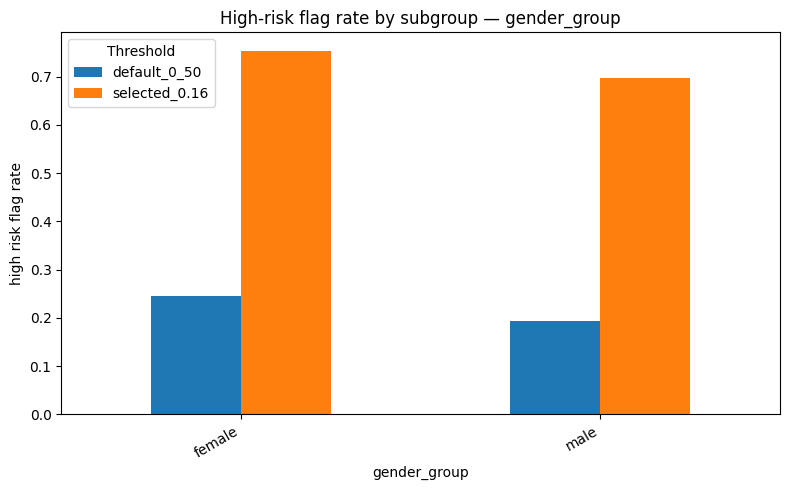

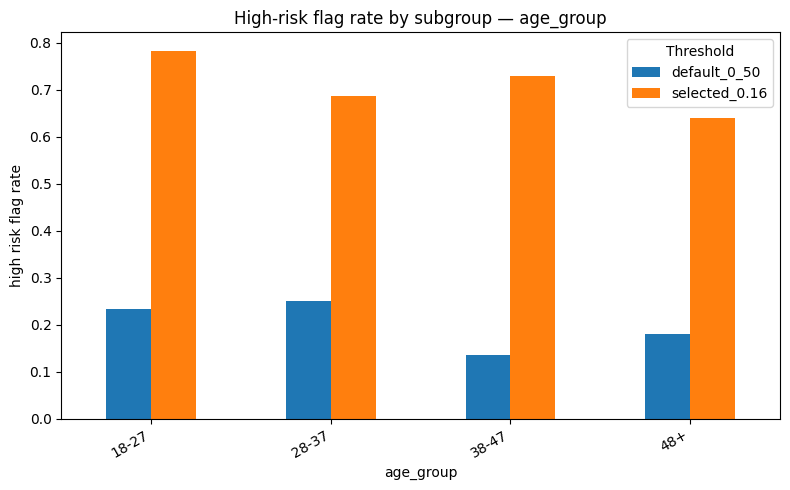

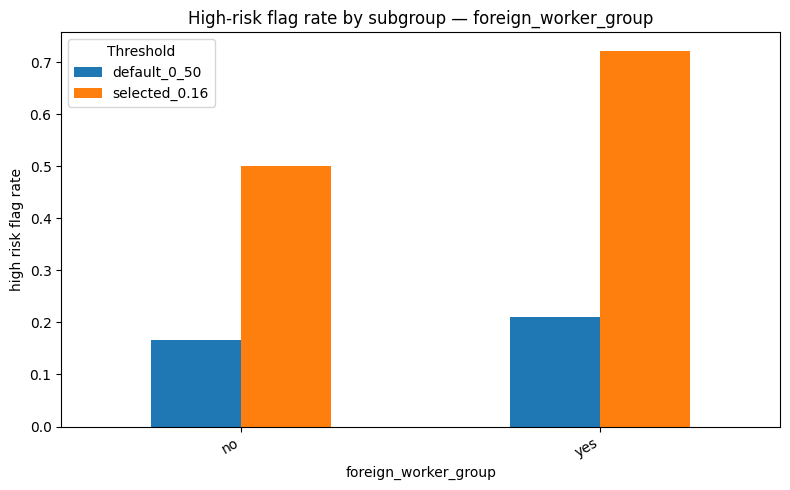

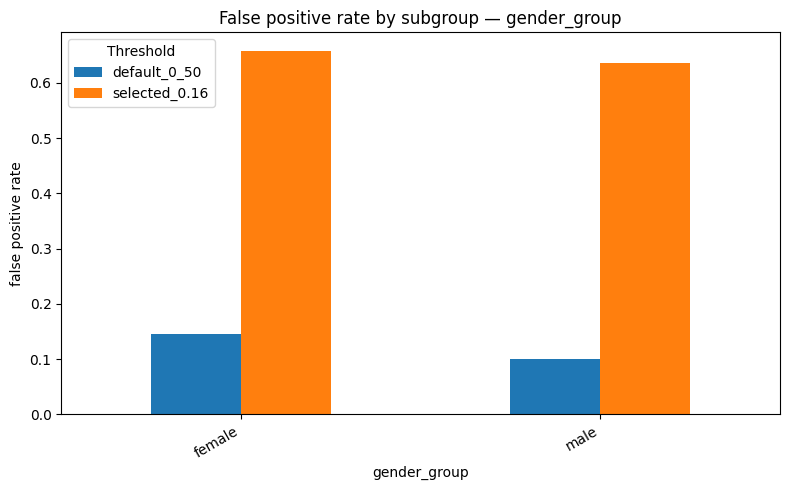

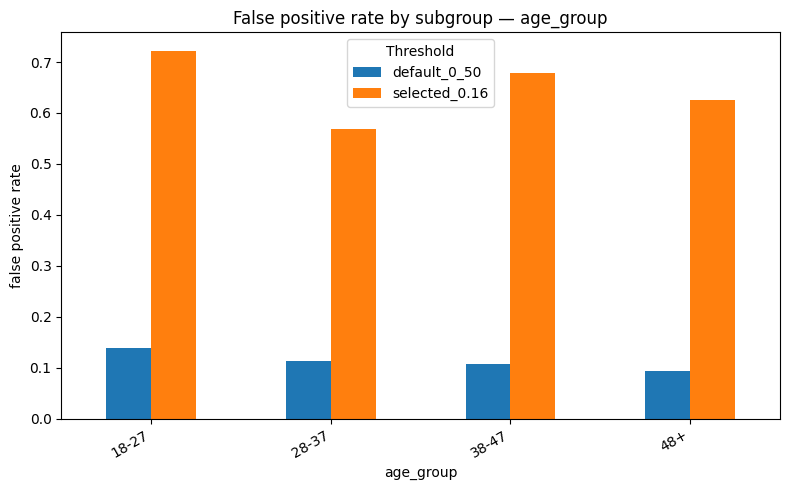

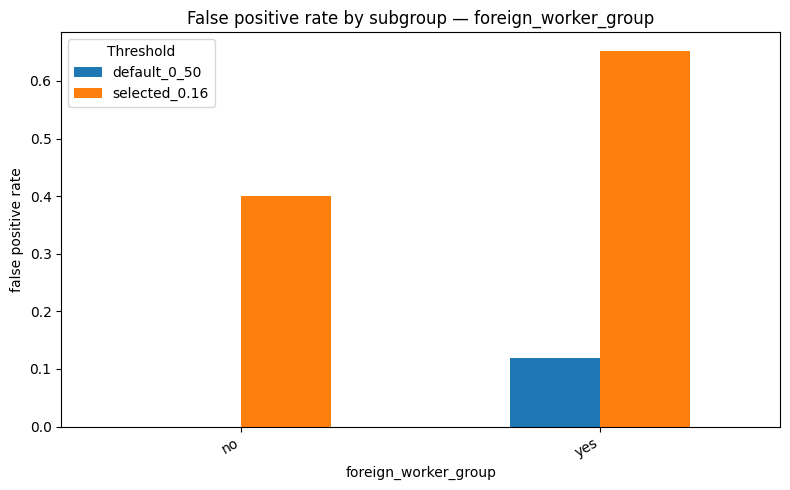

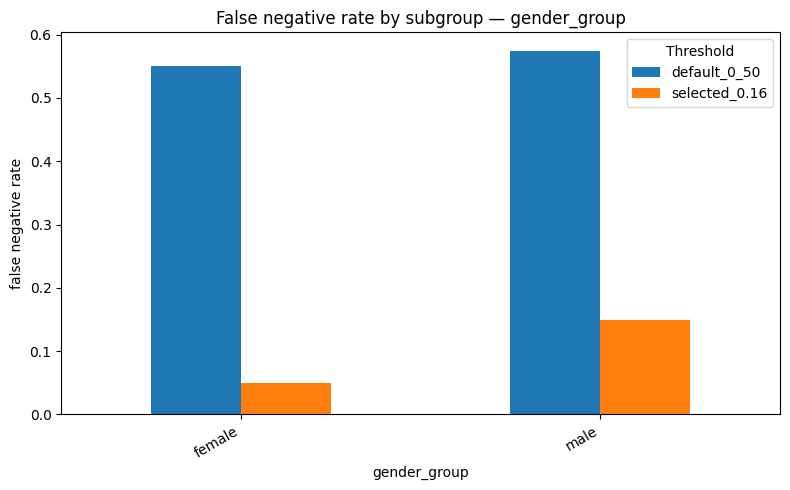

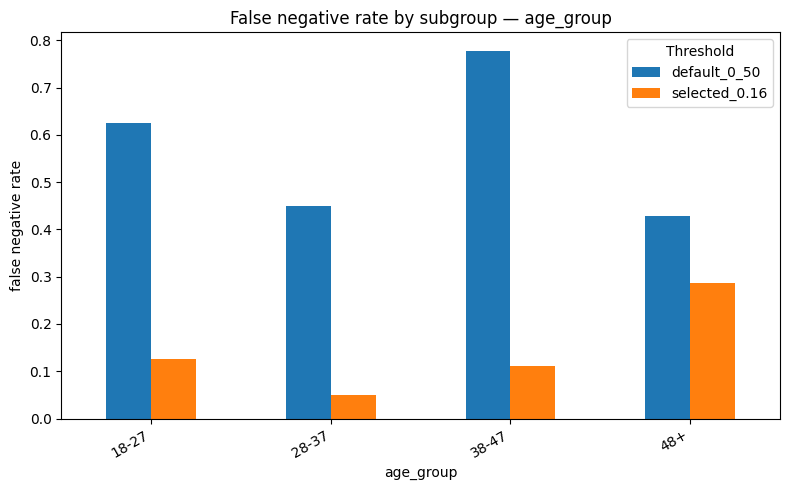

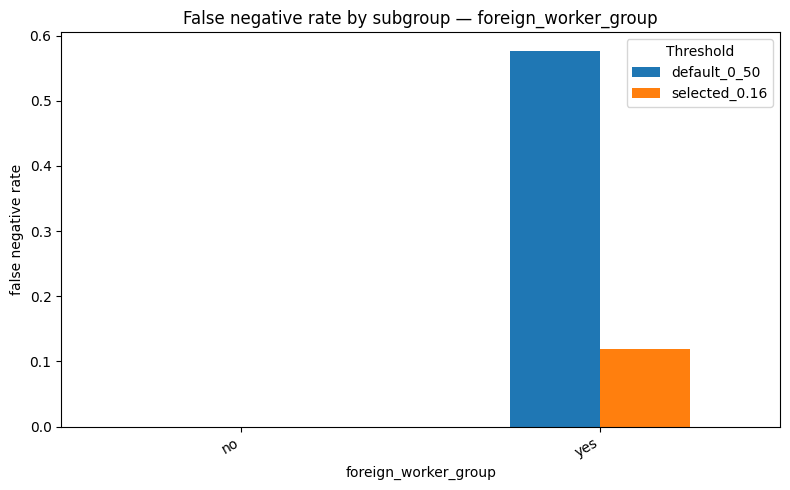

In [12]:
def plot_subgroup_metric(metric, title, filename):
    for attribute in SUBGROUP_COLUMNS:
        plot_df = subgroup_metrics_df[subgroup_metrics_df["attribute"] == attribute].copy()
        pivot = plot_df.pivot(index="group", columns="threshold", values=metric)
        pivot = pivot.sort_index()

        ax = pivot.plot(kind="bar", figsize=(8, 5))
        ax.set_title(f"{title} — {attribute}")
        ax.set_xlabel(attribute)
        ax.set_ylabel(metric.replace("_", " "))
        ax.legend(title="Threshold")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"{filename}_{attribute}.png", dpi=150)
        plt.show()

plot_subgroup_metric("high_risk_flag_rate", "High-risk flag rate by subgroup", "high_risk_flag_rate")
plot_subgroup_metric("false_positive_rate", "False positive rate by subgroup", "false_positive_rate")
plot_subgroup_metric("false_negative_rate", "False negative rate by subgroup", "false_negative_rate")

## 8. Fairness Findings Screen

This is a rule-based screen to identify findings that deserve governance attention.

The thresholds below are not legal thresholds. They are practical review triggers for this portfolio case:

- favourable disparate impact ratio below `0.80`;
- high-risk flag rate gap above `0.20`;
- false positive or false negative rate gap above `0.20`;
- subgroup size below `30`, which makes estimates unstable.

In [13]:
FAVOURABLE_DI_TRIGGER = 0.80
RATE_GAP_TRIGGER = 0.20
MIN_GROUP_SIZE = 30

findings = []

for _, row in disparity_df.iterrows():
    severity = "Low"
    reasons = []

    if pd.notna(row["favourable_disparate_impact_ratio"]) and row["favourable_disparate_impact_ratio"] < FAVOURABLE_DI_TRIGGER:
        severity = "High"
        reasons.append("favourable outcome disparate impact ratio below 0.80")

    for metric in ["high_risk_flag_rate_gap", "false_positive_rate_gap", "false_negative_rate_gap"]:
        if pd.notna(row[metric]) and row[metric] > RATE_GAP_TRIGGER:
            severity = "Medium" if severity == "Low" else severity
            reasons.append(f"{metric} above {RATE_GAP_TRIGGER:.2f}")

    min_group_n = subgroup_metrics_df[
        (subgroup_metrics_df["threshold"] == row["threshold"]) &
        (subgroup_metrics_df["attribute"] == row["attribute"])
    ]["n"].min()

    if min_group_n < MIN_GROUP_SIZE:
        reasons.append(f"small subgroup size: minimum n = {min_group_n}")

    findings.append({
        "threshold": row["threshold"],
        "attribute": row["attribute"],
        "severity": severity,
        "main_reasons": "; ".join(reasons) if reasons else "no material review trigger",
        "min_group_size": min_group_n,
        "favourable_di_ratio": row["favourable_disparate_impact_ratio"],
        "high_risk_flag_rate_gap": row["high_risk_flag_rate_gap"],
        "false_positive_rate_gap": row["false_positive_rate_gap"],
        "false_negative_rate_gap": row["false_negative_rate_gap"],
    })

findings_df = pd.DataFrame(findings)

display(findings_df.round(4))
findings_df.to_csv(TABLES_DIR / "fairness_findings_screen.csv", index=False)

,threshold,attribute,severity,main_reasons,min_group_size,favourable_di_ratio,high_risk_flag_rate_gap,false_positive_rate_gap,false_negative_rate_gap
0,default_0_50,age_group,Medium,false_negative_rate_gap above 0.20,37,0.8672,0.1149,0.0451,0.3492
1,default_0_50,foreign_worker_group,Medium,false_negative_rate_gap above 0.20; small subg...,6,0.9464,0.0447,0.1185,0.5763
2,default_0_50,gender_group,Low,no material review trigger,61,0.9359,0.0517,0.0453,0.0250
3,selected_0.16,age_group,High,favourable outcome disparate impact ratio belo...,37,0.6036,0.1423,0.1540,0.2357
4,selected_0.16,foreign_worker_group,High,favourable outcome disparate impact ratio belo...,6,0.5567,0.2216,0.2519,0.1186
5,selected_0.16,gender_group,Low,no material review trigger,61,0.8138,0.0563,0.0222,0.1000


## 9. Explainability Setup

Notebook 01 saved predictions but not the fitted model. For explainability, this notebook reproduces the same model training logic:

- same dataset;
- same train / validation / test split;
- same selected base model;
- same sigmoid calibration.

The goal is to generate transparent evidence on the main drivers of the candidate model.

In [14]:
def load_german_credit_from_openml():
    data = fetch_openml(name="credit-g", version=1, as_frame=True)
    df = data.frame.copy()
    df["bad_risk"] = df["class"].astype(str).str.lower().map({"bad": 1, "good": 0})
    return df

df_full = load_german_credit_from_openml()

target_col = "class"
feature_cols = [c for c in df_full.columns if c not in [target_col, "bad_risk"]]

categorical_cols = [c for c in feature_cols if str(df_full[c].dtype) in ["category", "object", "string"]]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

X = df_full[feature_cols].copy()
y = df_full["bad_risk"].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", encoder, categorical_cols),
    ],
    remainder="drop"
)

base_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE))
])

final_model = CalibratedClassifierCV(estimator=base_model, method="sigmoid", cv=3)
final_model.fit(X_train, y_train)

test_scores_reproduced = final_model.predict_proba(X_test)[:, 1]

print("Reproduced model check:")
print(f"ROC AUC: {roc_auc_score(y_test, test_scores_reproduced):.3f}")
print(f"Average precision: {average_precision_score(y_test, test_scores_reproduced):.3f}")
print(f"Brier score: {brier_score_loss(y_test, test_scores_reproduced):.3f}")

Reproduced model check:
ROC AUC: 0.780
Average precision: 0.612
Brier score: 0.165


## 10. Permutation Importance

Permutation importance gives a simple view of which original features the model relies on most.

This is not a full individual explanation method. It is a global explainability check.

Responsible AI questions:

- Are the top drivers credit-relevant?
- Are any top drivers sensitive attributes or obvious proxies?
- Would the model be explainable enough for internal review and customer-facing reason codes?

In [15]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(15).round(4))
importance_df.to_csv(TABLES_DIR / "permutation_importance.csv", index=False)

,feature,importance_mean,importance_std
0,checking_status,0.0916,0.0279
2,credit_history,0.0322,0.0165
4,credit_amount,0.0307,0.0071
7,installment_commitment,0.0195,0.0108
1,duration,0.0179,0.0083
3,purpose,0.0150,0.0066
5,savings_status,0.0045,0.0082
19,foreign_worker,0.0040,0.0017
12,age,0.0033,0.0014
18,own_telephone,0.0015,0.0039


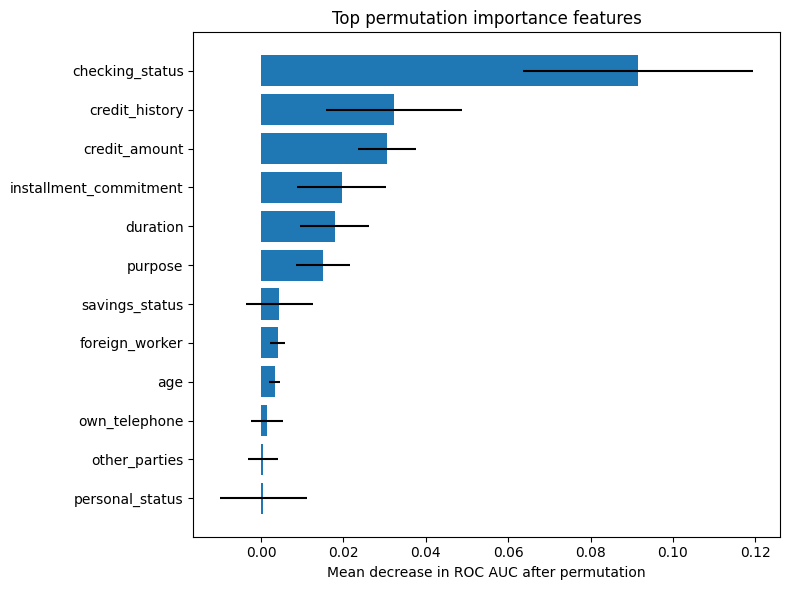

In [19]:
top_importance = importance_df.head(12).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance_mean"], xerr=top_importance["importance_std"])
plt.xlabel("Mean decrease in ROC AUC after permutation")
plt.title("Top permutation importance features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "permutation_importance_top_features.png", dpi=150)
plt.show()

## 11. Proxy and Explainability Review

This section creates a short review table for the top features.

The review is intentionally simple. It flags whether a feature is:

- directly credit-relevant;
- potentially sensitive or proxy-sensitive;
- requiring additional business/legal review before use in a real credit model.

In [16]:
def feature_review_note(feature):
    f = feature.lower()

    if "personal_status" in f or "sex" in f or "gender" in f:
        return "Sensitive/proxy-sensitive: should not be used without specific legal and governance review."
    if "age" in f:
        return "Sensitive or legally constrained in many credit contexts; requires explicit policy review."
    if "foreign_worker" in f:
        return "Proxy-sensitive: may relate to nationality/migration status; requires legal and fairness review."
    if "employment" in f:
        return "Credit-relevant but may create indirect socioeconomic disparities; monitor subgroup effects."
    if "housing" in f:
        return "Credit-relevant proxy candidate; check whether it drives unequal outcomes."
    if "checking_status" in f or "savings_status" in f or "credit_history" in f or "duration" in f or "amount" in f:
        return "Generally credit-relevant, but still requires reason-code and proportionality review."
    return "Review for business relevance and potential proxy effect."

explainability_review = importance_df.head(15).copy()
explainability_review["review_note"] = explainability_review["feature"].apply(feature_review_note)

display(explainability_review.round(4))
explainability_review.to_csv(TABLES_DIR / "explainability_review_top_features.csv", index=False)

,feature,importance_mean,importance_std,review_note
0,checking_status,0.0916,0.0279,"Generally credit-relevant, but still requires ..."
2,credit_history,0.0322,0.0165,"Generally credit-relevant, but still requires ..."
4,credit_amount,0.0307,0.0071,"Generally credit-relevant, but still requires ..."
7,installment_commitment,0.0195,0.0108,Review for business relevance and potential pr...
1,duration,0.0179,0.0083,"Generally credit-relevant, but still requires ..."
3,purpose,0.0150,0.0066,Review for business relevance and potential pr...
5,savings_status,0.0045,0.0082,"Generally credit-relevant, but still requires ..."
19,foreign_worker,0.0040,0.0017,Proxy-sensitive: may relate to nationality/mig...
12,age,0.0033,0.0014,Sensitive or legally constrained in many credi...
18,own_telephone,0.0015,0.0039,Review for business relevance and potential pr...


## 12. Mitigation Options Considered

Mitigation is not applied automatically.

The right sequence is:

1. diagnose subgroup and error disparities;
2. decide which risk is material;
3. select a mitigation that targets that risk;
4. compare the mitigation against performance, fairness and operational impact.

Options considered for this case:

| Option | When it would be relevant | Comment |
|---|---|---|
| Threshold adjustment | If the selected threshold creates excessive customer friction or subgroup disparity | Most directly connected to current finding |
| Reweighing / sample weighting | If one subgroup is underrepresented or systematically disadvantaged | Useful, but should follow diagnosis |
| Feature review | If top features are sensitive or proxy-sensitive | Strong governance control |
| Post-processing constraints | If error rates differ sharply across groups | More complex; may be harder to justify operationally |
| Human review | If automated flagging is too aggressive for direct action | Likely required here |
| Monitoring | If the model proceeds to pilot | Needed for subgroup performance and drift |

For this V1, the main mitigation is not a new algorithm. The main mitigation is controlled use: decision-support only, human review, subgroup monitoring, and threshold review.

## 13. Responsible AI Findings Table

This table translates the technical results into governance findings.

It is designed to be copied into the fairness assessment and AI risk-control matrix.

In [17]:
findings_for_governance = []

selected_overall = overall_comparison[overall_comparison["threshold"].str.startswith("selected")].iloc[0]
default_overall = overall_comparison[overall_comparison["threshold"] == "default_0_50"].iloc[0]

findings_for_governance.append({
    "finding": "Cost-sensitive threshold creates high flagging rate",
    "evidence": (
        f"High-risk flag rate increases from {default_overall['high_risk_flag_rate']:.1%} "
        f"to {selected_overall['high_risk_flag_rate']:.1%}; "
        f"false negatives fall from {int(default_overall['false_negatives'])} "
        f"to {int(selected_overall['false_negatives'])}."
    ),
    "risk": "Customer exclusion risk and manual review workload may become excessive.",
    "severity": "High",
    "recommended_control": "Do not use for automated rejection; apply human review and threshold governance."
})

for _, row in findings_df.iterrows():
    if row["severity"] in ["High", "Medium"]:
        findings_for_governance.append({
            "finding": f"Subgroup disparity trigger for {row['attribute']} at {row['threshold']}",
            "evidence": row["main_reasons"],
            "risk": "Potential unequal customer impact or unstable subgroup performance.",
            "severity": row["severity"],
            "recommended_control": "Review subgroup metrics, validate on larger data, and monitor subgroup error rates."
        })

top_features = ", ".join(importance_df.head(5)["feature"].tolist())
findings_for_governance.append({
    "finding": "Main model drivers require business and proxy review",
    "evidence": f"Top permutation importance features: {top_features}.",
    "risk": "Some drivers may be difficult to justify or may act as proxies for sensitive characteristics.",
    "severity": "Medium",
    "recommended_control": "Review top features with credit risk, legal/compliance and business stakeholders."
})

governance_findings_df = pd.DataFrame(findings_for_governance)

display(governance_findings_df)
governance_findings_df.to_csv(TABLES_DIR / "responsible_ai_governance_findings.csv", index=False)

,finding,evidence,risk,severity,recommended_control
0,Cost-sensitive threshold creates high flagging...,High-risk flag rate increases from 21.0% to 71...,Customer exclusion risk and manual review work...,High,Do not use for automated rejection; apply huma...
1,Subgroup disparity trigger for age_group at de...,false_negative_rate_gap above 0.20,Potential unequal customer impact or unstable ...,Medium,"Review subgroup metrics, validate on larger da..."
2,Subgroup disparity trigger for foreign_worker_...,false_negative_rate_gap above 0.20; small subg...,Potential unequal customer impact or unstable ...,Medium,"Review subgroup metrics, validate on larger da..."
3,Subgroup disparity trigger for age_group at se...,favourable outcome disparate impact ratio belo...,Potential unequal customer impact or unstable ...,High,"Review subgroup metrics, validate on larger da..."
4,Subgroup disparity trigger for foreign_worker_...,favourable outcome disparate impact ratio belo...,Potential unequal customer impact or unstable ...,High,"Review subgroup metrics, validate on larger da..."
5,Main model drivers require business and proxy ...,Top permutation importance features: checking_...,Some drivers may be difficult to justify or ma...,Medium,"Review top features with credit risk, legal/co..."


## 14. Results to Copy into Governance Artefacts

The next cell prints a compact summary for the markdown artefacts.

In [18]:
selected_threshold_label = f"selected_{selected_threshold:.2f}"

high_risk_default = default_overall["high_risk_flag_rate"]
high_risk_selected = selected_overall["high_risk_flag_rate"]

fn_default = int(default_overall["false_negatives"])
fn_selected = int(selected_overall["false_negatives"])
fp_default = int(default_overall["false_positives"])
fp_selected = int(selected_overall["false_positives"])

highest_findings = governance_findings_df[governance_findings_df["severity"].isin(["High", "Medium"])]

findings_text = highest_findings[["finding", "severity"]].to_string(index=False)
importance_text = importance_df.head(8)[["feature", "importance_mean"]].round(4).to_string(index=False)

results_text = f"""
# Results to Copy into Governance Artefacts

## Fairness Testing Setup

- Favourable outcome: applicant is not flagged as high risk.
- Unfavourable outcome: applicant is flagged as high risk.
- Positive model class: bad credit risk.
- Tested attributes: gender group, age group, foreign worker status.
- Thresholds reviewed: default threshold 0.50 and selected cost-sensitive threshold {selected_threshold:.2f}.

## Overall Threshold Impact

At threshold 0.50:
- High-risk flag rate: {high_risk_default:.1%}
- False positives: {fp_default}
- False negatives: {fn_default}

At selected threshold {selected_threshold:.2f}:
- High-risk flag rate: {high_risk_selected:.1%}
- False positives: {fp_selected}
- False negatives: {fn_selected}

Interpretation: the selected threshold substantially reduces missed bad-risk applicants, but it also creates a much higher high-risk flag rate. This increases customer-friction risk and manual review workload.

## Subgroup Fairness Review

Subgroup metrics were calculated for:
- gender group;
- age group;
- foreign worker status.

Key finding screen:
{findings_text}

## Explainability Review

Top global drivers based on permutation importance:
{importance_text}

Interpretation: the model relies on several credit-relevant variables, but top drivers should be reviewed for business justification and potential proxy effects before operational use.

## Mitigation and Controls

No algorithmic mitigation is applied automatically in this notebook.

Recommended controls:
- use as decision-support only;
- no fully automated rejection;
- human review for adverse or borderline cases;
- subgroup monitoring after deployment or pilot;
- threshold review before approval;
- review of top model drivers with business, legal/compliance and risk stakeholders;
- consider reweighing, threshold adjustment or post-processing only if subgroup disparities are confirmed as material and stable.

## Responsible AI Conclusion

The candidate model is suitable for further controlled testing, not direct deployment. The main issue is not only model performance; it is the operating threshold. The selected cost-sensitive threshold improves bad-risk detection but creates high customer-friction risk and must be reviewed against subgroup fairness, explainability, operational capacity and human oversight requirements.
"""

print(results_text)

with open(TABLES_DIR / "results_to_copy_into_fairness_artefacts.md", "w") as f:
    f.write(results_text)


# Results to Copy into Governance Artefacts

## Fairness Testing Setup

- Favourable outcome: applicant is not flagged as high risk.
- Unfavourable outcome: applicant is flagged as high risk.
- Positive model class: bad credit risk.
- Tested attributes: gender group, age group, foreign worker status.
- Thresholds reviewed: default threshold 0.50 and selected cost-sensitive threshold 0.16.

## Overall Threshold Impact

At threshold 0.50:
- High-risk flag rate: 21.0%
- False positives: 16
- False negatives: 34

At selected threshold 0.16:
- High-risk flag rate: 71.5%
- False positives: 90
- False negatives: 7

Interpretation: the selected threshold substantially reduces missed bad-risk applicants, but it also creates a much higher high-risk flag rate. This increases customer-friction risk and manual review workload.

## Subgroup Fairness Review

Subgroup metrics were calculated for:
- gender group;
- age group;
- foreign worker status.

Key finding screen:
                              

## 15. Files Saved

This notebook saves:

- `outputs/tables/fairness_overall_threshold_comparison.csv`
- `outputs/tables/subgroup_metrics_by_threshold.csv`
- `outputs/tables/subgroup_disparity_summary.csv`
- `outputs/tables/fairness_findings_screen.csv`
- `outputs/tables/permutation_importance.csv`
- `outputs/tables/explainability_review_top_features.csv`
- `outputs/tables/responsible_ai_governance_findings.csv`
- `outputs/tables/results_to_copy_into_fairness_artefacts.md`
- `outputs/figures/high_risk_flag_rate_[attribute].png`
- `outputs/figures/false_positive_rate_[attribute].png`
- `outputs/figures/false_negative_rate_[attribute].png`
- `outputs/figures/permutation_importance_top_features.png`

Next step: use these outputs to write the fairness assessment, testing summary and AI risk-control matrix.